<a href="https://colab.research.google.com/github/jonaire-tate/dx702-experimental-design/blob/main/DX702_CodingQuiz_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DX702 Homework Reflections
Jonaire Tate | Boston University OMDS | May 2026

## Week 3 Coding Quiz: Event Studies and Differences-in-Differences

### Questions 1 & 2: Event Study Regression on value1

In [ ]:
# Load dataset - Event Study
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df3 = pd.read_csv('homework_3.1.csv')
df3.head()

,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132


#### Step 1: Explore the data

In [ ]:
# Explore the dataset
print(df3.shape)
print(df3['time'].min(), df3['time'].max())

(100, 4)
0 99


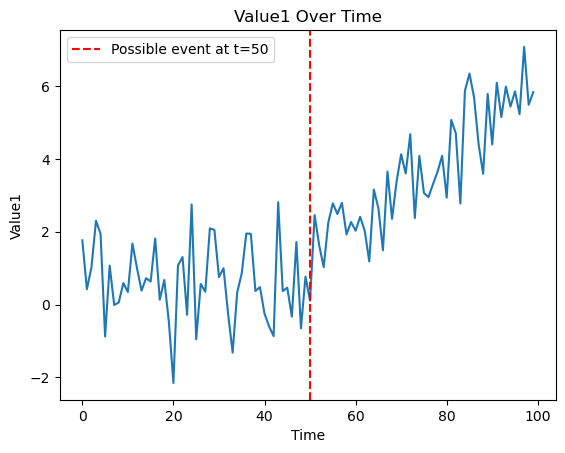

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df3['time'], df3['value1'])
plt.axvline(x=50, color='red', linestyle='--', label='Possible event at t=50')
plt.xlabel('Time')
plt.ylabel('Value1')
plt.title('Value1 Over Time')
plt.legend()
plt.show()

#### Step 2: Build event study variables

We set the event at t=50, which is where the plot shows a clear change in slope. We create two new variables:
- `after`: equals 0 before the event, 1 after
- `time_since_event`: equals 0 before the event, then counts up from 0 after it

In [ ]:
# Build event study variables
t0 = 50

df3['after'] = (df3['time'] >= t0).astype(int)
df3['time_since_event'] = (df3['time'] - t0) * df3['after']

df3[['time', 'after', 'time_since_event']].head(55).tail(10)

,time,after,time_since_event
45,45,0,0
46,46,0,0
47,47,0,0
48,48,0,0
49,49,0,0
50,50,1,0
51,51,1,1
52,52,1,2
53,53,1,3
54,54,1,4


#### Step 3: Model 1 - Discontinuity in value only (level jump, no slope change)

This model tests whether the event caused a sudden jump in the level of value1 at t=50, without allowing for a change in slope.

In [ ]:
# Model 1: level jump only
model1 = smf.ols('value1 ~ time + after', data=df3).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Sat, 30 May 2026   Prob (F-statistic):           6.48e-23
Time:                        21:46:02   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4439      0.271     -1.640      0.1

#### Step 4: Model 2 - Discontinuity in value and slope

This model tests for both a level jump (after) and a change in slope (time_since_event) at the event.

In [ ]:
# Model 2: level jump AND slope change
model2 = smf.ols('value1 ~ time + after + time_since_event', data=df3).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.18e-32
Time:                        21:46:46   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.8464      0.266  

#### Interpretation

Model 1 tested for a level jump only. The `after` coefficient was not significant (p=0.086), suggesting the event did not simply cause a one-time jump in value1.

Model 2 added a slope change term. Both `after` (p=0.020) and `time_since_event` (p=0.000) are statistically significant. The event caused a level jump of approximately 0.90 units AND increased the rate of growth by 0.105 units per time period. Model 2 fits the data much better (R-squared 0.790 vs 0.651).

#### Step 5: Compare level jump and slope change across all three values

In [ ]:
# Model 1 (level jump) and Model 2 (slope change) for all three values
for col in ['value1', 'value2', 'value3']:
    m1 = smf.ols(f'{col} ~ time + after', data=df3).fit()
    m2 = smf.ols(f'{col} ~ time + after + time_since_event', data=df3).fit()
    print(f'{col}:')
    print(f'  Level jump (after):            coef={m1.params["after"]:.4f}, p={m1.pvalues["after"]:.4f}')
    print(f'  Slope change (time_since_event): coef={m2.params["time_since_event"]:.4f}, p={m2.pvalues["time_since_event"]:.4f}')
    print()

value1:
  Level jump (after):            coef=0.8508, p=0.0856
  Slope change (time_since_event): coef=0.1053, p=0.0000

value2:
  Level jump (after):            coef=0.6827, p=0.1131
  Slope change (time_since_event): coef=0.0369, p=0.0118

value3:
  Level jump (after):            coef=1.7673, p=0.0000
  Slope change (time_since_event): coef=0.0507, p=0.0002



#### Interpretation

For the level jump (Question 1), value3 has the strongest and only statistically significant discontinuity in value at t=50 (coef=1.767, p=0.000).

For the slope change (Question 2), value1 has the strongest and most significant discontinuity in the derivative at t=50 (coef=0.105, p=0.000).

## Questions 3-5: Differences-in-Differences

#### Step 1: Load both datasets

In [ ]:
# Load both DiD datasets
df_a = pd.read_csv('homework_3.2.a.csv')
df_b = pd.read_csv('homework_3.2.b.csv')

print('Dataset A:')
print(df_a.head())
print()
print('Dataset B:')
print(df_b.head())

Dataset A:
   group1  time1  outcome1
0       0      0  0.882026
1       0      1  1.600079
2       0      0  0.489369
3       0      1  2.520447
4       0      0  0.933779

Dataset B:
   group2  time2  outcome2
0       0      0  0.667155
1       0      1  2.470969
2       0      0 -0.506778
3       0      1  1.525657
4       0      0  0.273664


#### Step 2: Run DiD regression on both datasets

In [ ]:
# DiD requires an interaction term: treated = group * time
df_a['treated'] = df_a['group1'] * df_a['time1']
df_b['treated'] = df_b['group2'] * df_b['time2']

# Run DiD regression on dataset A
model_a = smf.ols('outcome1 ~ group1 + time1 + treated', data=df_a).fit()
print('Dataset A (Group 1):')
print(f'  Treatment effect (treated): coef={model_a.params["treated"]:.4f}, p={model_a.pvalues["treated"]:.4f}')
print()

# Run DiD regression on dataset B
model_b = smf.ols('outcome2 ~ group2 + time2 + treated', data=df_b).fit()
print('Dataset B (Group 2):')
print(f'  Treatment effect (treated): coef={model_b.params["treated"]:.4f}, p={model_b.pvalues["treated"]:.4f}')

Dataset A (Group 1):
  Treatment effect (treated): coef=0.6858, p=0.0000

Dataset B (Group 2):
  Treatment effect (treated): coef=1.3499, p=0.0000


In [ ]:
# Compare standard errors
print('Dataset A (Group 1):')
print(f'  SE: {model_a.bse["treated"]:.4f}')
print()
print('Dataset B (Group 2):')
print(f'  SE: {model_b.bse["treated"]:.4f}')

Dataset A (Group 1):
  SE: 0.0625

Dataset B (Group 2):
  SE: 0.1470


In [ ]:
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Sat, 30 May 2026   Prob (F-statistic):          9.62e-235
Time:                        22:01:03   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1021      0.073      1.392      0.1

#### Interpretation

Dataset A (Group 1) has a treatment effect of 0.6858 and Dataset B (Group 2) has a larger treatment effect of 1.3499, making Group 2 the answer to Question 3.

For Question 4, Group 1 has a smaller standard error (0.0625 vs 0.1470), meaning its treatment effect is estimated more precisely and is more statistically significant.

For Question 5, the treatment effect for Group 2 is 1.3499, which is closest to 1.248.

#### Reflection Question 1: Testing for a change in the second derivative

In [ ]:
# Add squared time_since_event to test for second derivative change
df3['time_since_event_sq'] = df3['time_since_event'] ** 2

model3 = smf.ols('value1 ~ time + after + time_since_event + time_since_event_sq', data=df3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     89.58
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.23e-31
Time:                        22:06:20   Log-Likelihood:                -135.16
No. Observations:                 100   AIC:                             280.3
Df Residuals:                      95   BIC:                             293.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.8464    

#### Reflection Question 2: Custom DiD Scenario - Pharmacist-Led Medication Review Program

A hospital network introduces a pharmacist-led medication review program at some locations (treatment group) and not others (control group). We test whether the program reduced medication errors using a differences-in-differences regression.

In [ ]:
import numpy as np
np.random.seed(42)

n = 200

# Control group: no program, small natural improvement over time
control_before = np.random.normal(10, 2, n)
control_after = np.random.normal(9, 2, n)

# Treatment group: program reduces errors by about 3 units
treatment_before = np.random.normal(10, 2, n)
treatment_after = np.random.normal(6, 2, n)

df_q2 = pd.DataFrame({
    'errors': np.concatenate([control_before, control_after, treatment_before, treatment_after]),
    'group': np.concatenate([np.zeros(n), np.zeros(n), np.ones(n), np.ones(n)]),
    'time': np.concatenate([np.zeros(n), np.ones(n), np.zeros(n), np.ones(n)])
})

df_q2['treated'] = df_q2['group'] * df_q2['time']

model_q2 = smf.ols('errors ~ group + time + treated', data=df_q2).fit()
print(model_q2.summary())

                            OLS Regression Results                            
Dep. Variable:                 errors   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     175.3
Date:                Sat, 30 May 2026   Prob (F-statistic):           3.14e-87
Time:                        22:10:37   Log-Likelihood:                -1674.3
No. Observations:                 800   AIC:                             3357.
Df Residuals:                     796   BIC:                             3375.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.9185      0.139     71.315      0.0

#### Interpretation

The treated coefficient is -3.064 (p=0.000), indicating a statistically significant reduction of approximately 3 medication errors per hospital attributable to the pharmacist-led review program. The time coefficient of -0.747 shows that errors declined naturally over time for both groups, but the treatment group experienced a much larger reduction. This nonzero treatment effect confirms that the program had a real impact beyond what time alone would explain.